c:\Users\zxzy2\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


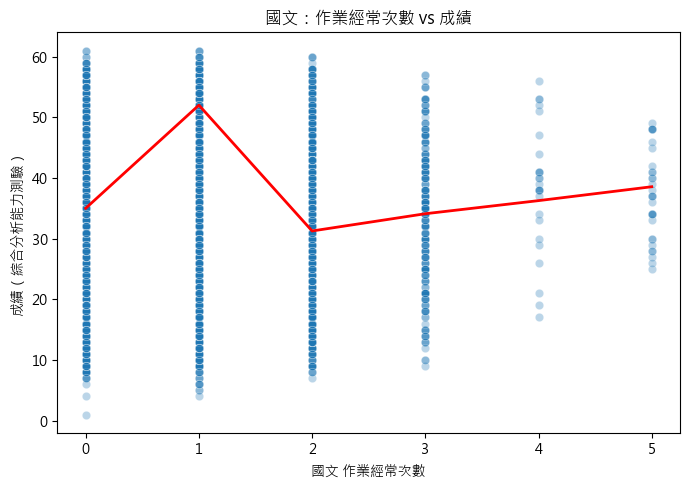

c:\Users\zxzy2\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


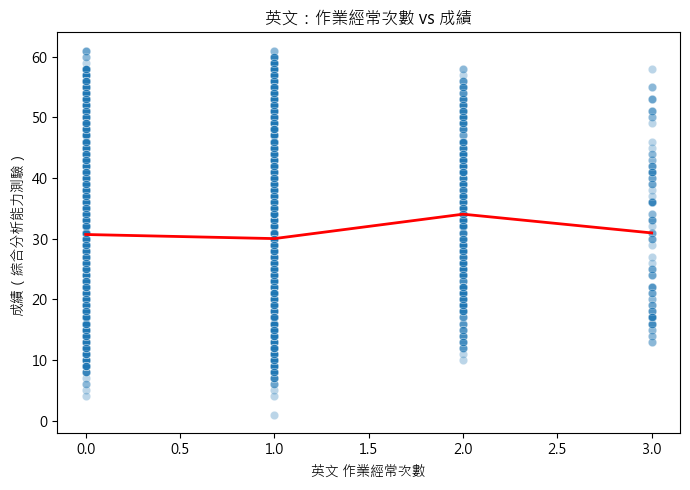

c:\Users\zxzy2\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


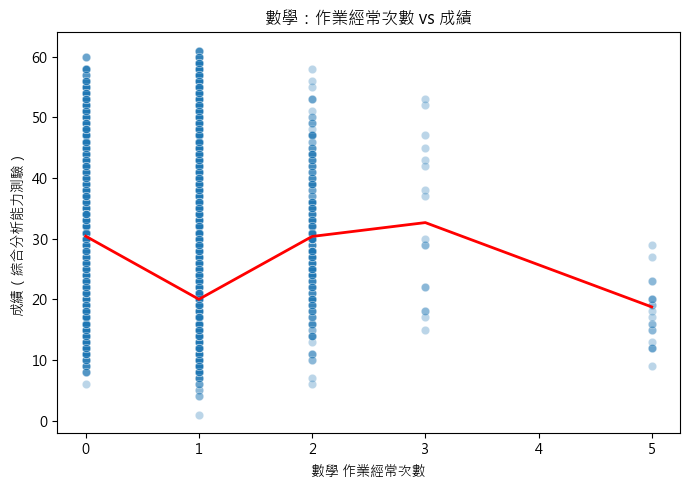

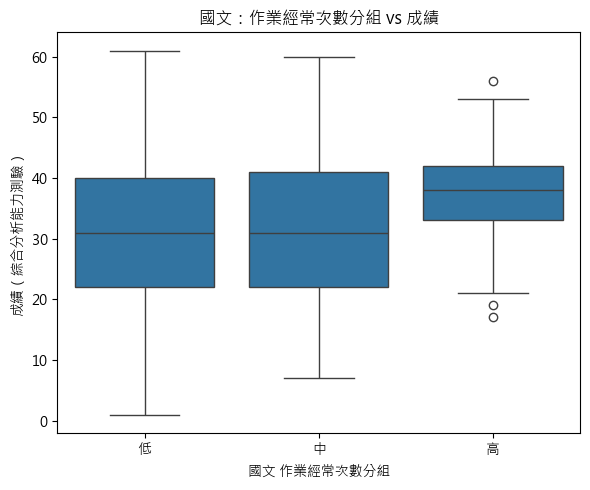

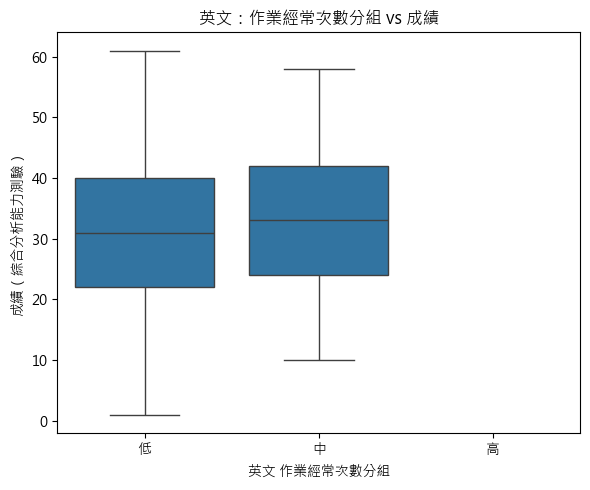

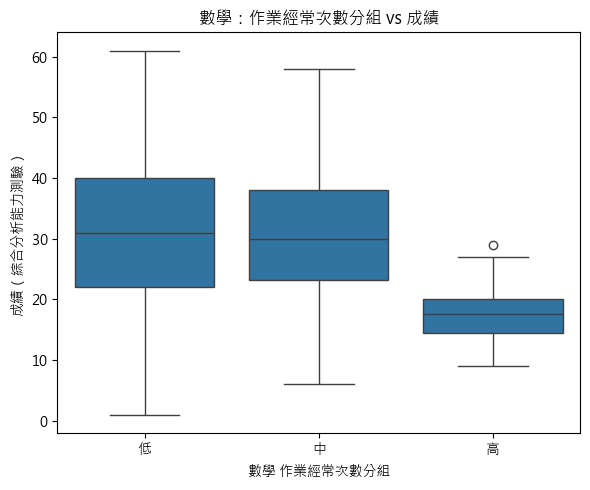


國文：作業數量（二次項）迴歸結果

                            OLS Regression Results                            
Dep. Variable:           綜合分析能力測驗答對題數   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     10.98
Date:                Tue, 23 Dec 2025   Prob (F-statistic):           1.72e-05
Time:                        19:10:26   Log-Likelihood:                -65615.
No. Observations:               17069   AIC:                         1.312e+05
Df Residuals:                   17066   BIC:                         1.313e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         31.2588      0.138 

In [1]:
# ================================================
#  項目 2：作業數量 vs 成績
# ================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib

matplotlib.rc('font', family='Microsoft JhengHei')

#-------------------------------------------------
# 1. 讀取資料
#-------------------------------------------------
df = pd.read_csv("cleaned_merged_ch.csv", encoding="utf-8-sig", low_memory=False)

#-------------------------------------------------
# 2. 設定分析欄位
#-------------------------------------------------
score_col = "綜合分析能力測驗答對題數"

hw_freq_cols = {
    "國文": "作業經常次數_國文",
    "英文": "作業經常次數_英文",
    "數學": "作業經常次數_數學"
}

#-------------------------------------------------
# 3. 散點圖 + LOWESS（檢查是否非線性）
#-------------------------------------------------
for subject, hw_col in hw_freq_cols.items():
    sub_df = df[[hw_col, score_col]].dropna()

    plt.figure(figsize=(7,5))
    sns.scatterplot(
        x=sub_df[hw_col],
        y=sub_df[score_col],
        alpha=0.3
    )

    # LOWESS 平滑線
    lowess_line = lowess(
        sub_df[score_col],
        sub_df[hw_col],
        frac=0.3
    )
    plt.plot(lowess_line[:,0], lowess_line[:,1], color="red", linewidth=2)

    plt.xlabel(f"{subject} 作業經常次數")
    plt.ylabel("成績（綜合分析能力測驗）")
    plt.title(f"{subject}：作業經常次數 vs 成績")
    plt.tight_layout()
    plt.show()

#-------------------------------------------------
# 4. 分組箱型圖（低 / 中 / 高）
#-------------------------------------------------
for subject, hw_col in hw_freq_cols.items():
    sub_df = df[[hw_col, score_col]].dropna()

    sub_df["作業量分組"] = pd.cut(
        sub_df[hw_col],
        bins=[-1, 1, 3, 10],
        labels=["低", "中", "高"]
    )

    plt.figure(figsize=(6,5))
    sns.boxplot(
        x="作業量分組",
        y=score_col,
        data=sub_df
    )

    plt.xlabel(f"{subject} 作業經常次數分組")
    plt.ylabel("成績（綜合分析能力測驗）")
    plt.title(f"{subject}：作業經常次數分組 vs 成績")
    plt.tight_layout()
    plt.show()

#-------------------------------------------------
# 5. 二次項迴歸（正式檢驗「過多反而下降」）
#-------------------------------------------------
for subject, hw_col in hw_freq_cols.items():
    sub_df = df[[hw_col, score_col]].dropna()

    X = pd.DataFrame({
        "hw": sub_df[hw_col],
        "hw_sq": sub_df[hw_col] ** 2
    })
    X = sm.add_constant(X)
    y = sub_df[score_col]

    model = sm.OLS(y, X).fit()

    print("\n====================================")
    print(f"{subject}：作業數量（二次項）迴歸結果")
    print("====================================\n")
    print(model.summary())


c:\Users\zxzy2\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


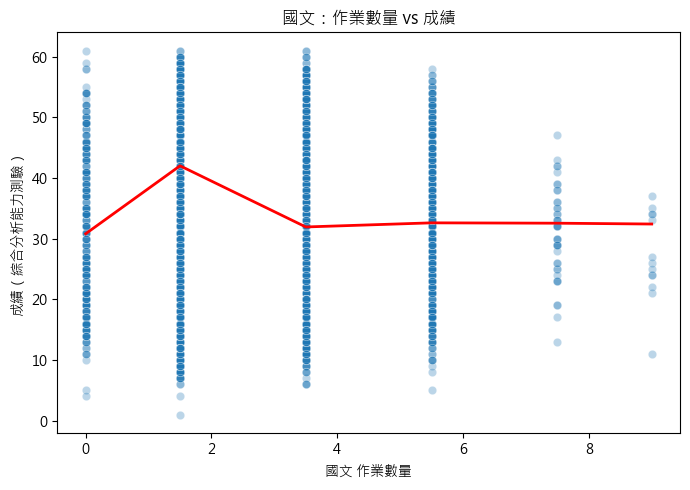

c:\Users\zxzy2\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


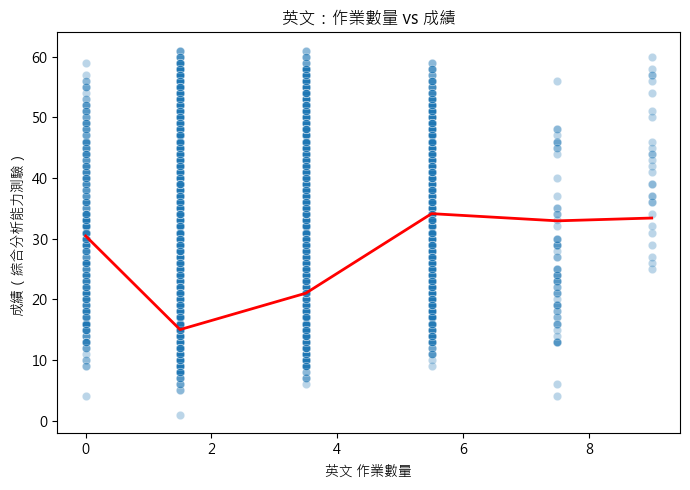

c:\Users\zxzy2\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


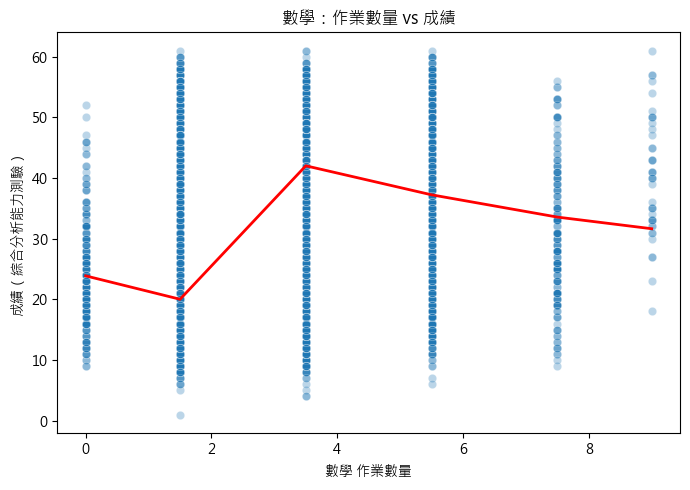

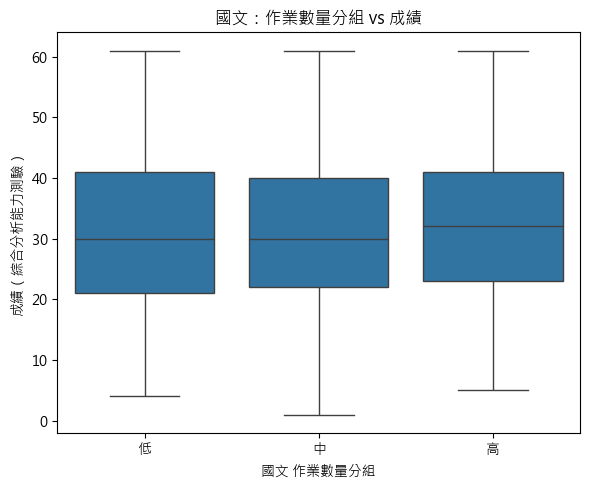

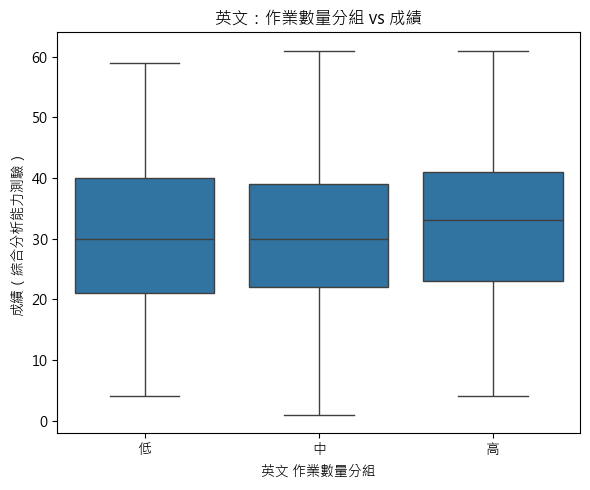

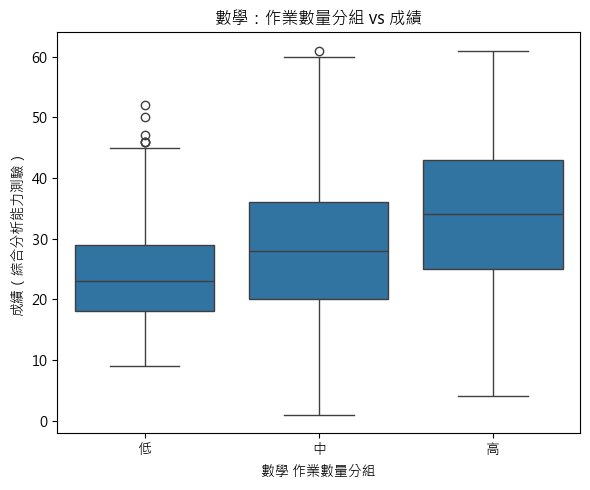


國文：作業數量（二次項）迴歸結果

                            OLS Regression Results                            
Dep. Variable:           綜合分析能力測驗答對題數   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     10.32
Date:                Tue, 23 Dec 2025   Prob (F-statistic):           3.33e-05
Time:                        19:10:27   Log-Likelihood:                -65458.
No. Observations:               17029   AIC:                         1.309e+05
Df Residuals:                   17026   BIC:                         1.309e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         30.3571      0.359 

In [2]:
# ================================================
#  項目 2：作業數量 vs 成績
# ================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib

matplotlib.rc('font', family='Microsoft JhengHei')

#-------------------------------------------------
# 1. 讀取資料
#-------------------------------------------------
df = pd.read_csv("cleaned_merged_ch.csv", encoding="utf-8-sig", low_memory=False)

#-------------------------------------------------
# 2. 設定分析欄位
#-------------------------------------------------
score_col = "綜合分析能力測驗答對題數"

hw_freq_cols = {
    "國文": "每周作業頻率標準化_國文",
    "英文": "每周作業頻率標準化_英文",
    "數學": "每周作業頻率標準化_數學"
}

#-------------------------------------------------
# 3. 散點圖 + LOWESS（檢查是否非線性）
#-------------------------------------------------
for subject, hw_col in hw_freq_cols.items():
    sub_df = df[[hw_col, score_col]].dropna()

    plt.figure(figsize=(7,5))
    sns.scatterplot(
        x=sub_df[hw_col],
        y=sub_df[score_col],
        alpha=0.3
    )

    # LOWESS 平滑線
    lowess_line = lowess(
        sub_df[score_col],
        sub_df[hw_col],
        frac=0.3
    )
    plt.plot(lowess_line[:,0], lowess_line[:,1], color="red", linewidth=2)

    plt.xlabel(f"{subject} 作業數量")
    plt.ylabel("成績（綜合分析能力測驗）")
    plt.title(f"{subject}：作業數量 vs 成績")
    plt.tight_layout()
    plt.show()

#-------------------------------------------------
# 4. 分組箱型圖（低 / 中 / 高）
#-------------------------------------------------
for subject, hw_col in hw_freq_cols.items():
    sub_df = df[[hw_col, score_col]].dropna()

    sub_df["作業量分組"] = pd.cut(
        sub_df[hw_col],
        bins=[-1, 1, 3, 10],
        labels=["低", "中", "高"]
    )

    plt.figure(figsize=(6,5))
    sns.boxplot(
        x="作業量分組",
        y=score_col,
        data=sub_df
    )

    plt.xlabel(f"{subject} 作業數量分組")
    plt.ylabel("成績（綜合分析能力測驗）")
    plt.title(f"{subject}：作業數量分組 vs 成績")
    plt.tight_layout()
    plt.show()

#-------------------------------------------------
# 5. 二次項迴歸（正式檢驗「過多反而下降」）
#-------------------------------------------------
for subject, hw_col in hw_freq_cols.items():
    sub_df = df[[hw_col, score_col]].dropna()

    X = pd.DataFrame({
        "hw": sub_df[hw_col],
        "hw_sq": sub_df[hw_col] ** 2
    })
    X = sm.add_constant(X)
    y = sub_df[score_col]

    model = sm.OLS(y, X).fit()

    print("\n====================================")
    print(f"{subject}：作業數量（二次項）迴歸結果")
    print("====================================\n")
    print(model.summary())
